**Predicting Bike Rental Demand**

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Ridge, RidgeCV

Load the dataset for Task 1

In [116]:
df = pd.read_csv('FloridaBikeRentals.csv')

In [117]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(èš“),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(èš“),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


Check for null values in any columns and handle the missing values. 

In [118]:
df.info() # I choose to use df.info so that I can see if there was any null and the dtypes at the same time. 

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        8760 non-null   str    
 1   Rented Bike Count           8760 non-null   int64  
 2   Hour                        8760 non-null   int64  
 3   Temperature(èš“)            8760 non-null   float64
 4   Humidity(%)                 8760 non-null   int64  
 5   Wind speed (m/s)            8760 non-null   float64
 6   Visibility (10m)            8760 non-null   int64  
 7   Dew point temperature(èš“)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)     8760 non-null   float64
 9   Rainfall(mm)                8760 non-null   float64
 10  Snowfall (cm)               8760 non-null   float64
 11  Seasons                     8760 non-null   str    
 12  Holiday                     8760 non-null   str    
 13  Functioning Day             8760 non-null   

Convert Date columns to Date format and extract day, month, day of week, and weekdays/weekend from date column.


In [119]:
df['Date'] = pd.to_datetime(df['Date'], format="%d/%m/%Y")
print(df['Date'])

0      2017-12-01
1      2017-12-01
2      2017-12-01
3      2017-12-01
4      2017-12-01
          ...    
8755   2018-11-30
8756   2018-11-30
8757   2018-11-30
8758   2018-11-30
8759   2018-11-30
Name: Date, Length: 8760, dtype: datetime64[us]


In [120]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month

print(df[['Day','Month',]])


      Day  Month
0       1     12
1       1     12
2       1     12
3       1     12
4       1     12
...   ...    ...
8755   30     11
8756   30     11
8757   30     11
8758   30     11
8759   30     11

[8760 rows x 2 columns]


In [121]:
df['Weekday'] = df['Date'].dt.weekday
df['IsWeekend'] = ((df['Date'].dt.weekday == 5) | (df['Date'].dt.weekday == 6)).astype(int)
print(df[['Date', 'Weekday', 'IsWeekend']].head())

        Date  Weekday  IsWeekend
0 2017-12-01        4          0
1 2017-12-01        4          0
2 2017-12-01        4          0
3 2017-12-01        4          0
4 2017-12-01        4          0


Check correlation of features using heatmap.

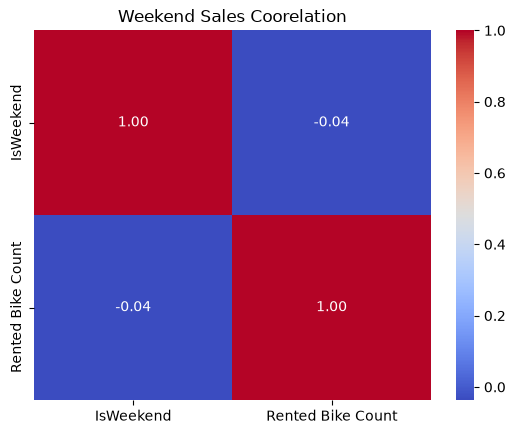

In [122]:
correlation_matrix = df[['IsWeekend','Rented Bike Count']].corr()

# Plot heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Weekend Sales Coorelation')
plt.show()

Plot the histogram of all numerical features.

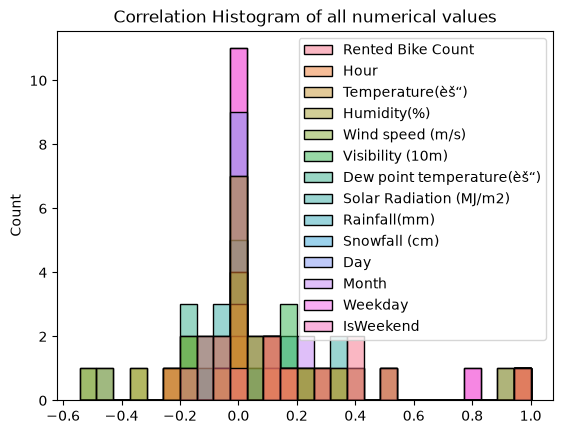

In [123]:
df_numerical = df.select_dtypes(include='number')
correlated = df_numerical.corr()

sns.histplot(correlated)
plt.title('Correlation Histogram of all numerical values')
plt.show()

Plot the box plot of Rented Bike Count against all the categorical features

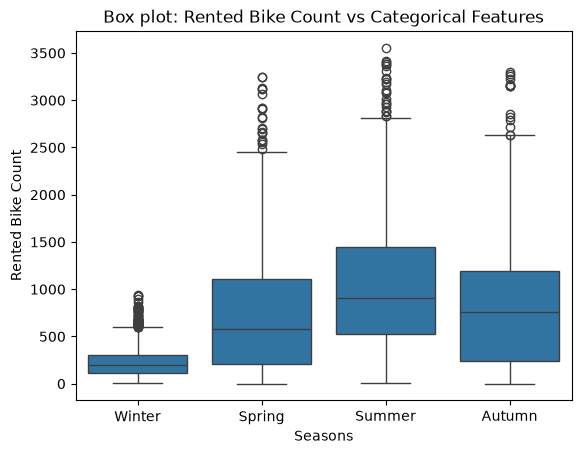

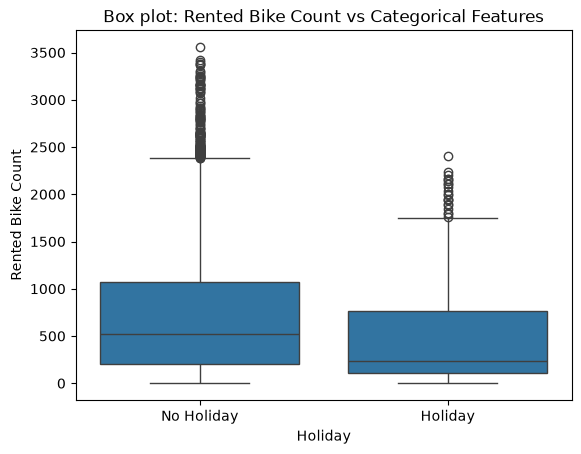

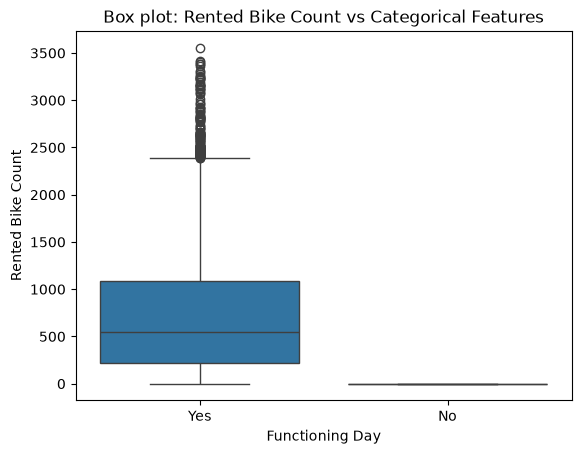

In [124]:
df_categorical = df.select_dtypes(include=['object', 'string', 'category'])

for categorical in df_categorical:
    sns.boxplot(x=df[categorical], y=df['Rented Bike Count'],)
    plt.title('Box plot: Rented Bike Count vs Categorical Features')
    plt.show()

Plot the Seaborn catplot of Rented Bike Count against features like Hour, Holiday, Rainfall (mm), Snowfall (cm), weekdays, weekend, and give your inferences.

Box plots for Hours, Holiday, Weekday, and Weekend

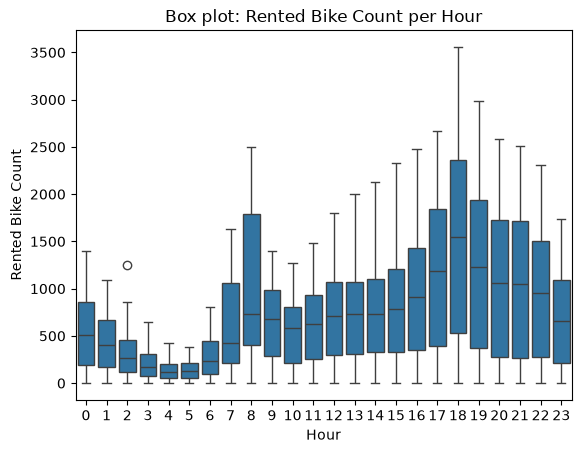

In [125]:
# Box Plot Hours
sns.boxplot(x=df['Hour'], y=df['Rented Bike Count'],)
plt.title('Box plot: Rented Bike Count per Hour')
plt.show()

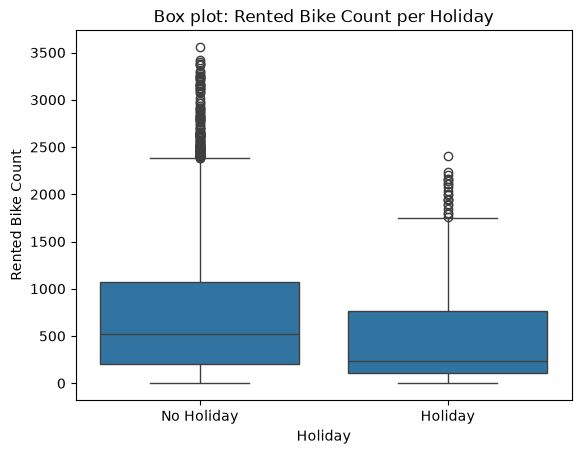

In [126]:
# Box Plot Hours
sns.boxplot(x=df['Holiday'], y=df['Rented Bike Count'],)
plt.title('Box plot: Rented Bike Count per Holiday')
plt.show()

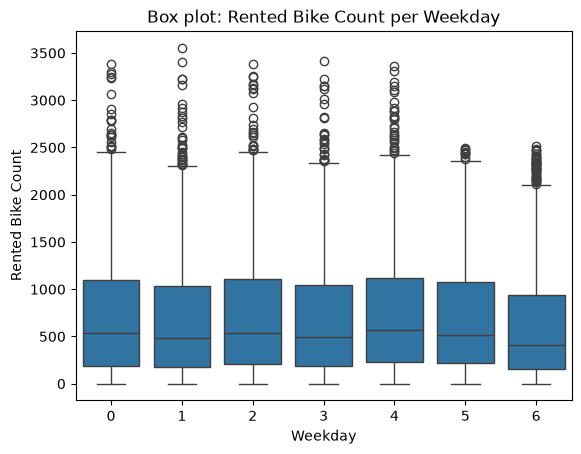

In [127]:
# Box Plot Weekdays
sns.boxplot(x=df['Weekday'], y=df['Rented Bike Count'],)
plt.title('Box plot: Rented Bike Count per Weekday')
plt.show()

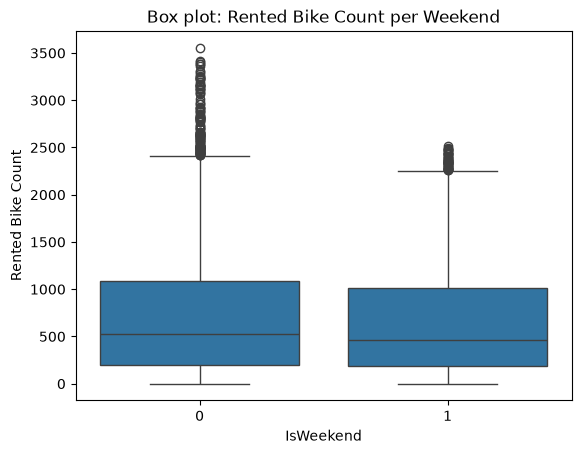

In [128]:
# Box Plot Weekend
sns.boxplot(x=df['IsWeekend'], y=df['Rented Bike Count'],)
plt.title('Box plot: Rented Bike Count per Weekend')
plt.show()

There’s a surprisingly even distribution of bike rentals throughout the week. I expected weekends to dominate, but the data shows people rent bikes consistently across all days. The chart also reveals that rentals are noticeably lower on holidays, which is another unexpected finding.

In [129]:
#Looking for the column with incudes 'datetime64' and dropping it since im not able to do the standard scaling with datetime64 strings.
date_cols = df.select_dtypes(include=['datetime64']).columns
df = df.drop(columns=date_cols)


Encode the categorical features into numerical features

In [130]:
df_encoded = pd.get_dummies(df, drop_first=False)
df_encoded

,Rented Bike Count,Hour,Temperature(èš“),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(èš“),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),...,Weekday,IsWeekend,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning Day_No,Functioning Day_Yes
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,...,4,0,False,False,False,True,False,True,False,True
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,...,4,0,False,False,False,True,False,True,False,True
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,...,4,0,False,False,False,True,False,True,False,True
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,...,4,0,False,False,False,True,False,True,False,True
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,...,4,0,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,...,4,0,True,False,False,False,False,True,False,True
8756,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,...,4,0,True,False,False,False,False,True,False,True
8757,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,...,4,0,True,False,False,False,False,True,False,True
8758,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,...,4,0,True,False,False,False,False,True,False,True


In [131]:
#Assign values to X and y
X = df_encoded.drop(['Rented Bike Count'], axis=1)
y = df_encoded['Rented Bike Count']

# Splitting the data into training and testing sets to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

In [132]:
# Perform Standardization on numerical features.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


In [133]:
X_train.head()

,Hour,Temperature(èš“),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(èš“),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Day,...,Weekday,IsWeekend,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning Day_No,Functioning Day_Yes
54,6,3.4,86,2.5,278,1.2,0.00,1.0,0.0,3,...,6,1,False,False,False,True,False,True,False,True
5748,12,33.6,62,1.9,820,25.3,1.35,0.0,0.0,28,...,5,1,False,False,True,False,False,True,False,True
8382,6,4.9,76,1.1,800,1.0,0.00,0.0,0.0,15,...,3,0,True,False,False,False,False,True,False,True
4228,4,14.8,73,0.5,994,9.9,0.00,0.0,0.0,26,...,5,1,False,True,False,False,False,True,False,True
7437,21,18.5,78,0.1,2000,14.5,0.00,0.0,0.0,6,...,5,1,True,False,False,False,False,True,False,True


Perform Linear Regression, Lasso Regression, and Ridge Regression to predict the bike count required each hour and compare the results.

In [134]:
#Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled,y_train)

# Training data
y_train_pred = lin_reg.predict(X_train_scaled)

# Test data
X_test_scaled = scaler.transform(X_test)
y_test_pred = lin_reg.predict(X_test_scaled)


In [135]:
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))

print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))


Train R²: 0.5542377876110008
Test R²: 0.551132785235908
MAE: 320.9669046881626
RMSE: 430.7117275998398


In [136]:
#Lasso Regression
lasso_model = Lasso(alpha=1, max_iter=10000).fit(X_train_scaled, y_train)
print("Lasso intercept:", lasso_model.intercept_)

Lasso intercept: 703.0933219178082


In [137]:
# Training data
pred_train = lasso_model.predict(X_train_scaled)
mse_train = mean_squared_error(y_train, pred_train)


# Test data
pred_test = lasso_model.predict(X_test_scaled)
mse_test =mean_squared_error(y_test, pred_test)


In [138]:
print("Train R²:", r2_score(y_train, pred_train))
print("Test R²:", r2_score(y_test, pred_test))

print("MAE:", mean_absolute_error(y_test, pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_test)))

Train R²: 0.5540581830690947
Test R²: 0.5513765801886852
MAE: 320.861312554543
RMSE: 430.5947446662487


In [139]:
#Ridge Regression
ridge_model = Ridge(alpha=1).fit(X_train_scaled, y_train)
ridge_model.intercept_

np.float64(703.0933219178082)

In [140]:
pred_train = ridge_model.predict(X_train_scaled)
mse_train = mean_squared_error(y_train, pred_train)
pred_test = ridge_model.predict(X_test_scaled)
mse_test =mean_squared_error(y_test, pred_test)

In [141]:
print("Train R²:", r2_score(y_train, pred_train))
print("Test R²:", r2_score(y_test, pred_test))

print("MAE:", mean_absolute_error(y_test, pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_test)))

Train R²: 0.5542376431076785
Test R²: 0.5511655784021439
MAE: 320.95932038310724
RMSE: 430.69599392760716


All three regression models Linear, Lasso, and Ridge achieved nearly identical performance, with R² values around 55%. Lasso Regression did performed slightly better, producing the lowest MAE and RMSE and the highest test R²